## Benckmark
**Comparação entre modelos**
* `gemini-3.1-flash-lite-preview`
* `gemini-3.1-flash-lite`
* `gpt-oss-20b (llama)`


## 1. librarys

In [1]:
import os
from dotenv import load_dotenv
import datetime
import time
import requests
import pandas as pd
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

from langchain_experimental.agents import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from io import StringIO


from langchain_core.globals import set_debug




# # Modelos LLM (Large Language Models)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_groq import ChatGroq

print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

/tmp/ipykernel_17255/3030909707.py:11: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.agents import create_pandas_dataframe_agent


# 21/08/2026 - 17:14:41


## 2. load envs

In [2]:
# 2. Carregamento das variáveis de ambiente (.env)
ENV_PATH: str = '/home/akel/PycharmProjects/InsurMinds2026/.env'

def carrega_variaveis_ambiente() -> None:
    if os.path.exists(ENV_PATH):
        load_dotenv(ENV_PATH, override=True)
        print("✔ Variáveis de ambiente carregadas do arquivo .env")
    else:
        print(f"⚠ Aviso: Arquivo {ENV_PATH} não foi encontrado no diretório atual.")

carrega_variaveis_ambiente()

llm_gemini_p = ChatGoogleGenerativeAI(temperature=0, model="gemini-3.1-flash-lite-preview",google_api_key=os.getenv("GOOGLE_API"))
llm_gemini_l = ChatGoogleGenerativeAI(temperature=0, model="gemini-3.1-flash-lite",thinking_level="low",google_api_key=os.getenv("GOOGLE_API"))
llm_llama    = ChatGroq(temperature=0,model="openai/gpt-oss-20b",api_key=os.getenv("GROQ_API"))

set_debug(False)
print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

✔ Variáveis de ambiente carregadas do arquivo .env
# 21/08/2026 - 17:14:41


## 3. dataset

In [3]:
# Dados extraídos da tabela
wiki_dados = {
    'Capital': [
        'Vitória', 'Florianópolis', 'Curitiba', 'São Luís', 'Palmas',
        'Brasília', 'Goiânia', 'Belo Horizonte', 'Cuiabá', 'São Paulo',
        'Campo Grande', 'Rio de Janeiro', 'Aracaju', 'Boa Vista', 'Teresina',
        'Porto Alegre', 'Recife', 'Fortaleza', 'Natal', 'João Pessoa',
        'Salvador', 'Belém', 'Macapá', 'Rio Branco', 'Manaus',
        'Porto Velho', 'Maceió'
    ],
    'idh2000': [
        0.700, 0.660, 0.655, 0.582, 0.508,
        0.582, 0.591, 0.617, 0.577, 0.614,
        0.548, 0.607, 0.519, 0.546, 0.488,
        0.612, 0.538, 0.534, 0.547, 0.523,
        0.525, 0.504, 0.478, 0.423, 0.443,
        0.469, 0.433
    ],
    'idh2010': [
        0.805, 0.800, 0.768, 0.752, 0.749,
        0.742, 0.739, 0.737, 0.726, 0.725,
        0.724, 0.719, 0.708, 0.708, 0.707,
        0.702, 0.698, 0.695, 0.694, 0.693,
        0.679, 0.673, 0.663, 0.661, 0.658,
        0.638, 0.635
    ]
}

# # Criando o DataFrame
dados_cidade = pd.DataFrame(wiki_dados)
## dicinario do data_frame
bases={'dados_cidade':dados_cidade}
print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

# 21/08/2026 - 17:14:41


## 4. tools, defs e agent

In [4]:
# AGENTE

def agente_teste(modelo=llm_gemini_p):


    #modelo = llm_gemini
    #modelo = llm_llama

    prompt = """
    Você é um agente especializado em análise de dados.
    Sempre utilize as ferramentas quando a resposta depender dos dados.

    Regras:
    - Não invente resultados.
    - Realize os cálculos usando o DataFrame disponível.
    - Não utilize print() no código Python.
    - Evite métodos que imprimem diretamente no console, como df.info().
    - Quando necessário, consulte a estrutura dos dados antes de calcular.
    - Responda em português.

    Formato da resposta:
    dado: dados_cidade
    dimensão: n x m
    informação consultada:
    ...
    """
  # new aproache using creat_pandas_dataframe
    agente = create_pandas_dataframe_agent(
        llm=modelo,
        df=dados_cidade,   #< aqui deve ser um df ou lista de df. Não um dicionario
        prefix=prompt,
        agent_type="tool-calling",
        verbose=False,
        allow_dangerous_code=True,
        return_intermediate_steps=True
    )

    return agente


# CAll/ASK/QUERY
def query(agente, pergunta):
    
    resposta = agente.invoke({
        "input": pergunta})

    #resposta['output'][0]['text']
    return resposta

print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

# 21/08/2026 - 17:14:41


## 5.funçoes de coleta e metrica

In [5]:
#funções

def contar_tokens(resposta):

    metricas = {
        "input_tokens": 0,
        "output_tokens": 0,
        "reasoning_tokens": 0,
        "total_tokens": 0
    }

    passos = resposta.get("intermediate_steps", [])

    for acao, resultado in passos:

        for mensagem in acao.message_log:

            usage = getattr(mensagem, "usage_metadata", None)

            if not usage:
                continue

            metricas["input_tokens"] += usage.get(
                "input_tokens", 0
            )

            metricas["output_tokens"] += usage.get(
                "output_tokens", 0
            )

            metricas["total_tokens"] += usage.get(
                "total_tokens", 0
            )

            detalhes = usage.get(
                "output_token_details", {}
            ) or {}

            metricas["reasoning_tokens"] += detalhes.get(
                "reasoning", 0
            )

    return metricas
def extrair_tools(resposta):

    passos = resposta.get("intermediate_steps", [])

    tools = []
    codigos = []

    for acao, resultado in passos:

        tools.append(acao.tool)

        if isinstance(acao.tool_input, dict):

            codigo = acao.tool_input.get("query")

            if codigo is not None:
                codigos.append(codigo)

    return {
        "n_tools": len(passos),
        "tools": tools,
        "codigo": codigos
    }
def extrair_metricas(resposta, tempo):

    tokens = contar_tokens(resposta)
    tools = extrair_tools(resposta)

    return {
        "tempo": tempo,

        "input_tokens": tokens["input_tokens"],
        "output_tokens": tokens["output_tokens"],
        "reasoning_tokens": tokens["reasoning_tokens"],
        "total_tokens": tokens["total_tokens"],

        "n_tools": tools["n_tools"],
        "tools": tools["tools"],
        "codigo": tools["codigo"]
    }

def executar_benchmark(
    agentes,
    pergunta,
    n=20
):

    resultados = []

    nomes = list(agentes.keys())

    for i in range(n):

        # alterna a ordem
        if i % 2 == 0:
            ordem = nomes
        else:
            ordem = nomes[::-1]

        for nome in ordem:

            agente = agentes[nome]

            inicio = time.perf_counter()

            resposta = query(
                agente,
                pergunta
            )

            tempo = (
                time.perf_counter()
                - inicio
            )

            metricas = extrair_metricas(
                resposta,
                tempo
            )

            metricas["execucao"] = i
            metricas["modelo"] = nome

            resultados.append(metricas)

    return pd.DataFrame(resultados)

def resumo_benchmark(df):

    resumo = (
        df
        .groupby("modelo")
        .agg(
            execucoes=("tempo", "count"),

            tempo_medio=("tempo", "mean"),
            tempo_mediano=("tempo", "median"),
            tempo_std=("tempo", "std"),
            tempo_min=("tempo", "min"),
            tempo_max=("tempo", "max"),

            input_tokens=("input_tokens", "mean"),
            output_tokens=("output_tokens", "mean"),
            reasoning_tokens=("reasoning_tokens", "mean"),
            total_tokens=("total_tokens", "mean"),

            tools_media=("n_tools", "mean")
        )
    )

    resumo["cv_tempo"] = (
        resumo["tempo_std"]
        / resumo["tempo_medio"]
    )

    return resumo



## 6.to Run

In [6]:
pergunta0="Quais dados estão disponiveis da base de dados?"

executor_gemini_p = agente_teste(llm_gemini_p)
executor_gemini_l = agente_teste(llm_gemini_l)
executor_llama = agente_teste(llm_llama)


agentes = {
    "gemini-3.1-flash-lite-preview": executor_gemini_p,
    "gemini-3.1-flash-lite(low)": executor_gemini_l,
    "GPT-OSS-20B": executor_llama
}

df_resultados = executar_benchmark(
    agentes=agentes,
    pergunta=pergunta0,
    n=20
)

resumo = resumo_benchmark(df_resultados)
display(resumo.round(3))

['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'idh2000', 'idh2010']
['Capital', 'i

,execucoes,tempo_medio,tempo_mediano,tempo_std,tempo_min,tempo_max,input_tokens,output_tokens,reasoning_tokens,total_tokens,tools_media,cv_tempo
modelo,,,,,,,,,,,,
GPT-OSS-20B,20,1.609,1.419,0.610,1.060,3.399,496.5,121.35,92.4,617.85,1.1,0.379
gemini-3.1-flash-lite(low),20,13.175,8.945,10.273,3.636,45.467,400.0,137.00,105.0,537.00,1.0,0.780
gemini-3.1-flash-lite-preview,20,6.845,5.403,6.209,1.842,29.633,400.0,33.00,0.0,433.00,1.0,0.907


## 7. plots

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def dashboard_benchmark(df):

    modelos = df["modelo"].unique()

    fig, axes = plt.subplots(
        3, 2,
        figsize=(15, 14)
    )

    # ========================================================
    # 1. Tempo por execução
    # ========================================================

    ax = axes[0, 0]

    for modelo in modelos:

        dados = df[df["modelo"] == modelo]

        ax.plot(
            dados["execucao"],
            dados["tempo"],
            marker="o",
            label=modelo
        )

    ax.set_title("Tempo por execução")
    ax.set_xlabel("Execução")
    ax.set_ylabel("Tempo (s)")
    ax.legend()
    ax.grid(alpha=0.3)


    # ========================================================
    # 2. Total de tokens por execução
    # ========================================================

    ax = axes[0, 1]

    for modelo in modelos:

        dados = df[df["modelo"] == modelo]

        ax.plot(
            dados["execucao"],
            dados["total_tokens"],
            marker="o",
            label=modelo
        )

    ax.set_title("Tokens por execução")
    ax.set_xlabel("Execução")
    ax.set_ylabel("Total de tokens")
    ax.legend()
    ax.grid(alpha=0.3)


    # ========================================================
    # 3. Boxplot da latência
    # ========================================================

    ax = axes[1, 0]

    dados_box = [
        df[df["modelo"] == modelo]["tempo"]
        for modelo in modelos
    ]

    ax.boxplot(
        dados_box,
        tick_labels=modelos
    )

    ax.set_title("Distribuição da latência")
    ax.set_ylabel("Tempo (s)")
    ax.grid(alpha=0.3)


    # ========================================================
    # 4. Tempo × tokens
    # ========================================================

    ax = axes[1, 1]

    for modelo in modelos:

        dados = df[df["modelo"] == modelo]

        ax.scatter(
            dados["total_tokens"],
            dados["tempo"],
            label=modelo
        )

    ax.set_title("Latência × tokens")
    ax.set_xlabel("Total de tokens")
    ax.set_ylabel("Tempo (s)")
    ax.legend()
    ax.grid(alpha=0.3)


    # ========================================================
    # 5. Média acumulada do tempo
    # ========================================================

    ax = axes[2, 0]

    for modelo in modelos:

        dados = (
            df[df["modelo"] == modelo]
            .sort_values("execucao")
            .copy()
        )

        dados["media_acumulada"] = (
            dados["tempo"].expanding().mean()
        )

        ax.plot(
            dados["execucao"],
            dados["media_acumulada"],
            marker="o",
            label=modelo
        )

    ax.set_title("Convergência da média de latência")
    ax.set_xlabel("Execução")
    ax.set_ylabel("Tempo médio acumulado (s)")
    ax.legend()
    ax.grid(alpha=0.3)


    # ========================================================
    # 6. Número de tools
    # ========================================================

    ax = axes[2, 1]

    for modelo in modelos:

        dados = df[df["modelo"] == modelo]

        ax.plot(
            dados["execucao"],
            dados["n_tools"],
            marker="o",
            label=modelo
        )

    ax.set_title("Chamadas de ferramentas")
    ax.set_xlabel("Execução")
    ax.set_ylabel("Número de tools")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

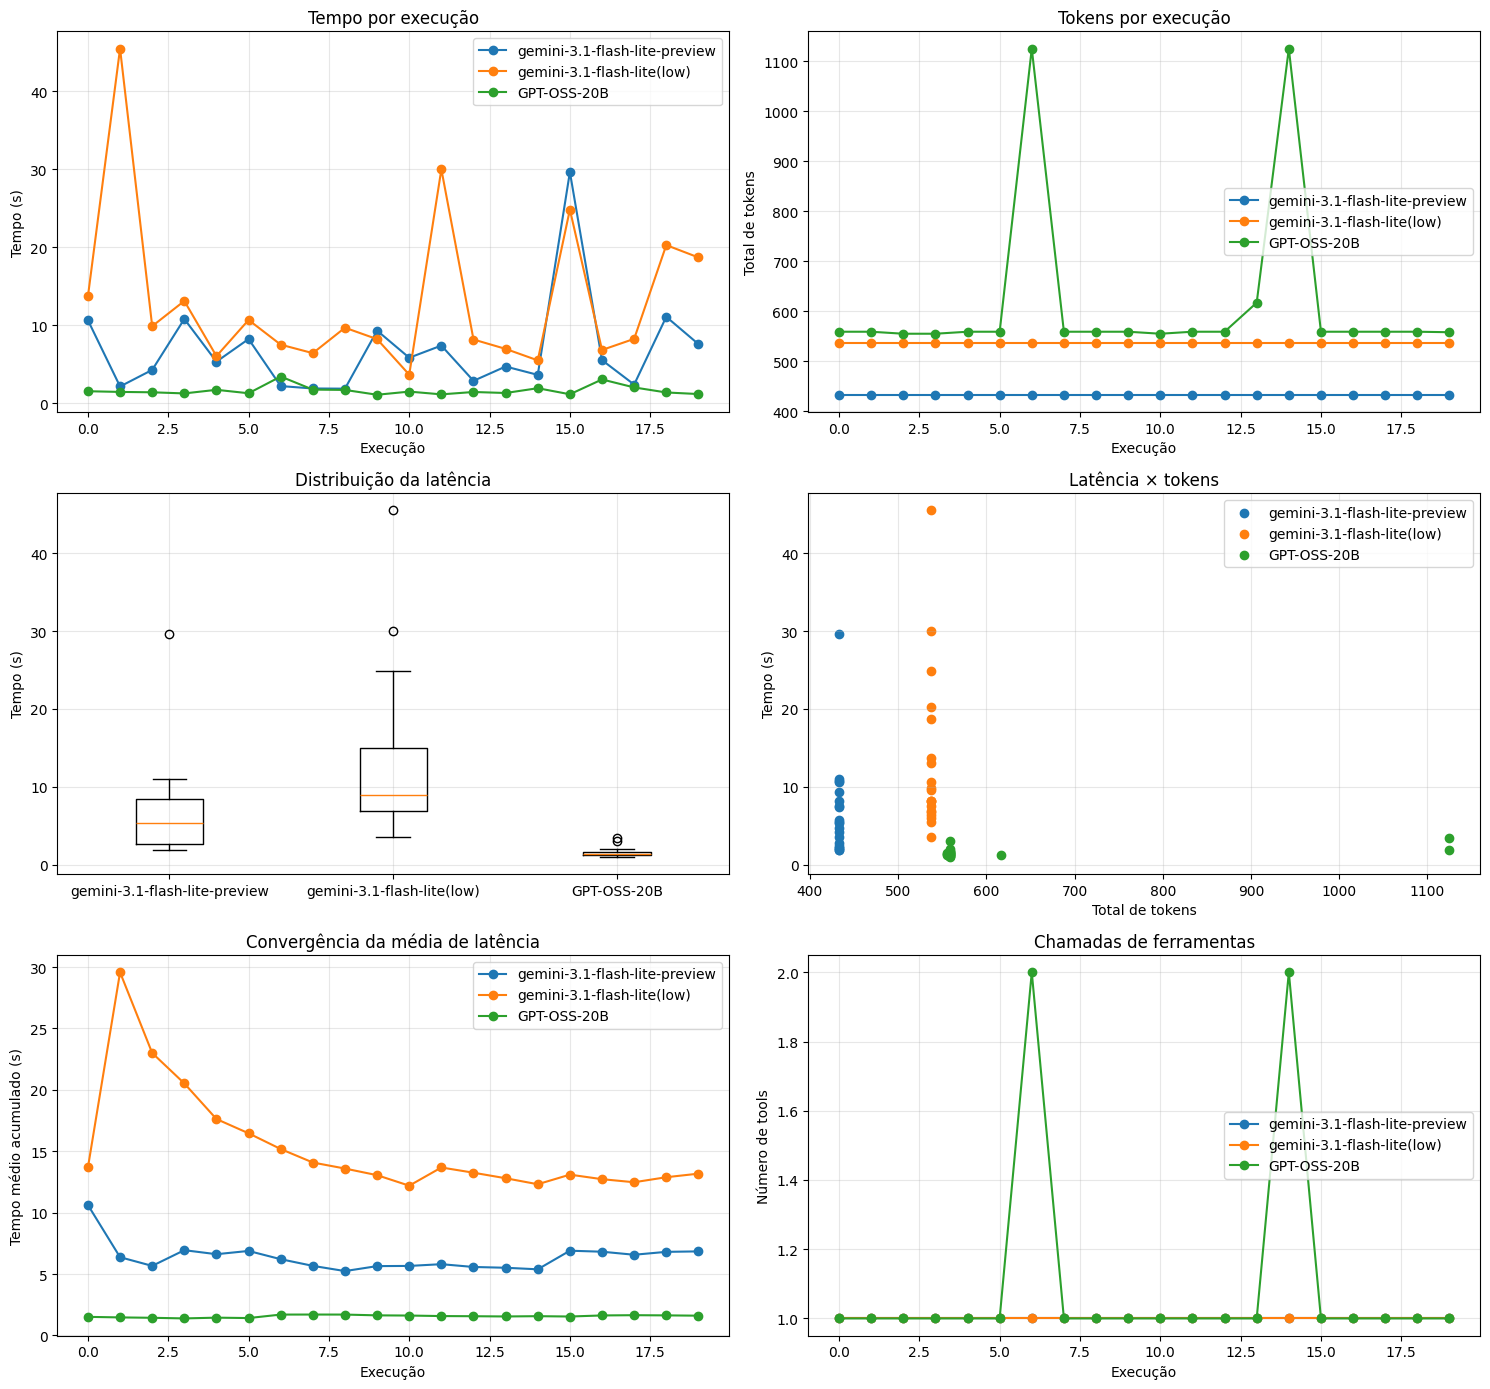

In [8]:
dashboard_benchmark(df_resultados)